### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
data.shape

(12684, 26)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [6]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


2. Investigate the dataset for missing or problematic data.

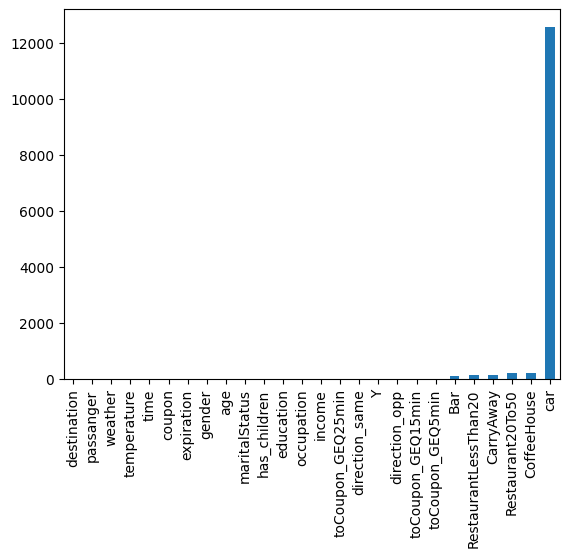

In [7]:
data.isnull().sum().sort_values().plot(kind = 'bar')
# plt.savefig('images/missing_plot_.png')
plt.show()

Investigated the values; it looks like the majority is null value or not observed.

In [8]:
# Check the count of values in car
data['car'].value_counts(dropna=False)

car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64

In [9]:
data[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']].apply(
    lambda x: x.value_counts(dropna=False)
)

,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
1~3,2473,3225,4672,5376,3290
4~8,1076,1784,4258,3580,728
gt8,349,1111,1594,1285,264
less1,3482,3385,1856,2093,6077
never,5197,2962,153,220,2136
NaN,107,217,151,130,189


3. Decide what to do about your missing data -- drop, replace, other...

- `car` has by far the largest number of missing values; all other columns have relatively small missing counts; I recommend to drop 'car'
- For the rest of the columns with missing values, I replaced them with 'unknown'; this avoids assumptions
- Because `never` represents zero visits and `less1` represents fewer than one visit per month, both categories were recoded as 0 to reflect no meaningful engagement. This allows a clearer distinction between low‑frequency and regular driver in the analysis.

In [10]:
# drop colume- car in data_clean- a copy of raw data
data_clean = data.drop(columns=['car'])

#Update Grouping classification

freq_cols = [
    'Bar', 'CoffeeHouse', 'CarryAway',
    'RestaurantLessThan20', 'Restaurant20To50'
]

#replace NaN with Unknown
data_clean[freq_cols] = data[freq_cols].fillna('Unknown')

# Replace less1 and never to 0
data_clean[freq_cols] = data_clean[freq_cols].replace({
    'less1': '0',
    'never': '0'
})

#replace gt8 to >8
data_clean[freq_cols] = data_clean[freq_cols].replace({
    'gt8': '>8'
})    

# Create numeric age column to help with filtering
age_map = {
    'below21': 20,
    '50plus': 50
}

data_clean['age_num'] = (
    data_clean['age']
    .replace(age_map)
    .astype(int)
)

In [11]:
data_clean[['age', 'age_num']].drop_duplicates().sort_values('age_num')

,age,age_num
1215,below21,20
0,21,21
110,26,26
259,31,31
677,36,36
281,41,41
44,46,46
409,50plus,50


4. What proportion of the total observations chose to accept the coupon?



57% chose to accept the coupon

In [12]:
acceptance_rate = data_clean['Y'].mean() * 100
round(acceptance_rate, 1)

np.float64(56.8)

5. Use a bar plot to visualize the `coupon` column.

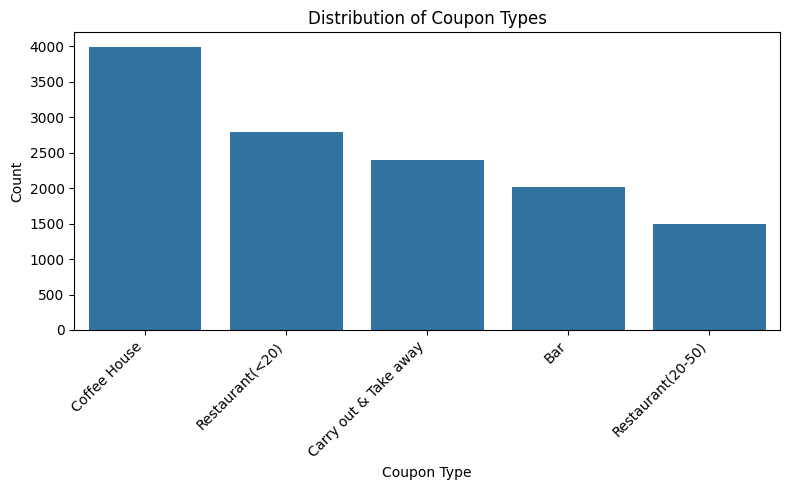

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data_clean,
    x='coupon',
    order=data_clean['coupon'].value_counts().index
)

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

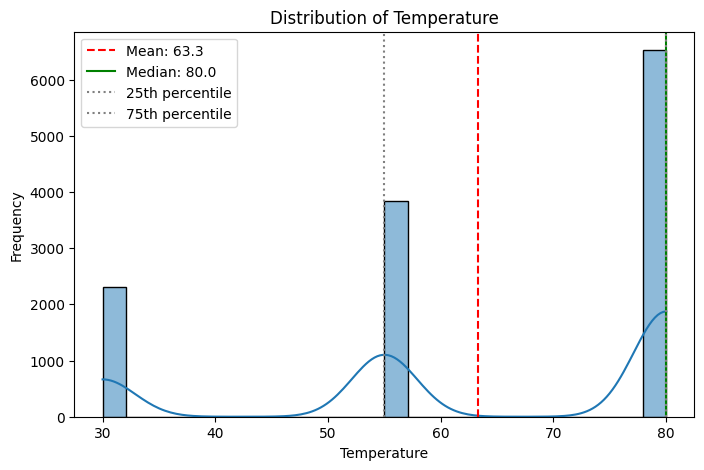

In [14]:
mean_val = data_clean['temperature'].mean()
median_val = data_clean['temperature'].median()
p25 = np.percentile(data_clean['temperature'], 25)
p75 = np.percentile(data_clean['temperature'], 75)

plt.figure(figsize=(8,5))
sns.histplot(data_clean['temperature'], bins='fd', kde=True)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')
plt.axvline(p25, color='gray', linestyle=':', label='25th percentile')
plt.axvline(p75, color='gray', linestyle=':', label='75th percentile')

plt.legend()
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

- The dataset is not evenly distributed across temperatures
- Warm conditions dominate, but cold outliers drag down the mean

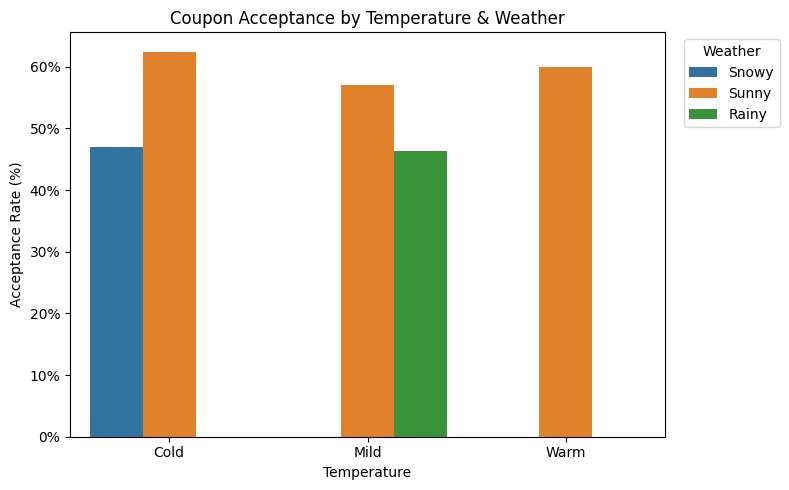

In [15]:
import matplotlib.ticker as mtick

# Create temp buckets
data_clean['temp_bucket'] = pd.cut(
    data_clean['temperature'],
    bins=[-float('inf'), 40, 70, float('inf')],
    labels=['Cold', 'Mild', 'Warm']
)

# Order by categories- Cold to Warm
data_clean['temp_bucket'] = pd.Categorical(
    data_clean['temp_bucket'],
    categories=['Cold', 'Mild', 'Warm'],
    ordered=True
)

# Group and aggregate (fixed warning)
pivot = (
    data_clean
    .groupby(['temp_bucket', 'weather'], observed=True)['Y']  # Driver accepted the coupon
    .mean()
    .reset_index()
)

# plotting and formatting
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=pivot,
    x='temp_bucket',
    y='Y',
    hue='weather'
)

# Format y-axis as %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Titles and labels
plt.title('Coupon Acceptance by Temperature & Weather')
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Temperature')

# Move legend outside
plt.legend(
    title='Weather',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()  # prevents clipping
plt.show()

- Including weather and temperature alongside acceptance rate helps identify when and under what conditions drivers are most likely to engage with coupons, enabling more targeted and effective marketing strategies.

- Coupon acceptance is highest in sunny weather across all temperature buckets (around 57–63%), indicating strong engagement in favorable conditions. In contrast, rainy and snowy conditions show lower acceptance (\~45–47%), especially in colder temperatures. Overall, warmer and sunnier conditions drive higher coupon usage.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [16]:
bar_coupon = data_clean[data_clean['coupon'] == 'Bar'].copy()

2. What proportion of bar coupons were accepted?


In [17]:
acceptance_rate = bar_coupon['Y'].mean() * 100
print(round(acceptance_rate, 1))

41.0


41% of bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [18]:
# Create bar_freq_Group to classify frequency Groupings; User goes a bar <=3 or >3 times a month
bar_filtered = bar_coupon[
    bar_coupon['Bar'].isin(['1~3', '4~8', '>8'])
].copy()

bar_filtered['bar_freq_group'] = '≤3'
bar_filtered.loc[
    bar_filtered['Bar'].isin(['4~8', '>8']),
    'bar_freq_group'
] = '>3'


In [19]:
acceptance_rate_q3 = (
    bar_filtered
    .groupby('bar_freq_group')['Y']   # Use the coupon
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name='acceptance_rate')
)

acceptance_rate_q3.style \
    .hide(axis="index") \
    .format({'acceptance_rate': '{:.1f}%'})

bar_freq_group,acceptance_rate
>3,76.9%
≤3,64.7%


- Acceptable Rate for users go to the bar greater than 3 times a month is 77%
- Acceptable Rate for users go to the bar 3 times or less a month is 65%

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [20]:
# Define "go to a bar more than once a month"
bar_more_than_once = bar_coupon['Bar'].isin(['1~3', '4~8', '>8'])

In [21]:
# Create descriptive Group labels
bar_coupon['Group'] = 'All other drivers'
bar_coupon.loc[
    bar_more_than_once & (bar_coupon['age_num'] > 25),
    'Group'
] = 'Bar > once/month & age > 25'

# Calculate acceptance rates
acceptance_rate_q4 = (
    bar_coupon
    .groupby('Group')['Y']
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name='Acceptance Rate (%)')
)

# Round Acceptable Rate to 1 decimal place
display(
    acceptance_rate_q4
    .style
    .format({'Acceptance Rate (%)': '{:.1f}'})
    .hide(axis='index')
)

Group,Acceptance Rate (%)
All other drivers,33.5
Bar > once/month & age > 25,69.5


Among Bar coupon users, drivers who go to a bar more than once a month and are over age 25 have a higher (70%) acceptance rate compared to all other drivers, suggesting that bar frequency combined with age may influence coupon acceptance.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [22]:
# Condition 2: passengers are NOT a kid
no_kid_passenger = ~bar_coupon['passanger'].isin(['Kid(s)'])

# Condition 3: occupation is NOT Farming, Fishing & Forestry
not_farming_job = bar_coupon['occupation'] != 'Farming Fishing & Forestry'

# Create descriptive Group labels
bar_coupon['Segment'] = 'All other drivers'
bar_coupon.loc[
    bar_more_than_once & no_kid_passenger & not_farming_job,
    'Segment'
] = 'Bar > once/month, no kids, non‑farming job'

# Calculate acceptance rates
acceptance_rate_q5 = (
    bar_coupon
    .groupby('Segment')['Y']
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name='Acceptance Rate (%)')
)

# Round Acceptable Rate to 1 decimal place
display(
    acceptance_rate_q5
    .style
    .format({'Acceptance Rate (%)': '{:.1f}'})
    .hide(axis='index')
)

Segment,Acceptance Rate (%)
All other drivers,29.6
"Bar > once/month, no kids, non‑farming job",71.3


71% of drivers with passengers not alone or with children and do to bars than tha once a month compare to all other drivers of 30%.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [23]:
# Create conditions to isolate specific characteristics of drivers:

# No kids in the car
no_kid_passenger = bar_coupon['passanger'] != 'Kid(s)'

# Not widowed
not_widowed = bar_coupon['maritalStatus'] != 'Widowed'

# Age under 30
age_under_30 = bar_coupon['age_num'] < 30

# Frequent cheap restaurant visits (more than 4 times/month)
cheap_rest_more_4 = bar_coupon['RestaurantLessThan20'].isin(['4~8', '>8'])

# Lower income group (< $50K)
income_lt_50k = bar_coupon['income'].isin([
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
])

# Build the three groups

cond_A = bar_more_than_once & no_kid_passenger & not_widowed
cond_B = bar_more_than_once & age_under_30
cond_C = cheap_rest_more_4 & income_lt_50k

# Calculate acceptance rates
acceptance_rates_q6 = pd.DataFrame({
    'Segment': [
        'Bar > once/month, no kids, not widowed',
        'Bar > once/month, age < 30',
        'Cheap rest > 4/month, income < 50K'
    ],
    'Acceptance Rate (%)': [
        bar_coupon.loc[cond_A, 'Y'].mean() * 100,
        bar_coupon.loc[cond_B, 'Y'].mean() * 100,
        bar_coupon.loc[cond_C, 'Y'].mean() * 100
    ]
}).round(1)

# Round Acceptable Rate to 1 decimal place
display(
    acceptance_rates_q6
    .style
    .format({'Acceptance Rate (%)': '{:.1f}'})
    .hide(axis='index')
)

Segment,Acceptance Rate (%)
"Bar > once/month, no kids, not widowed",71.3
"Bar > once/month, age < 30",72.2
"Cheap rest > 4/month, income < 50K",45.3


- The first two groups (both frequent bar-goers) have high and similar acceptance rates (~71–72%), indicating:
    * Lifestyle (social activity) strongly influences coupon acceptance.
- The third group has a much lower rate (45%), showing:
    * Relevance of the coupon (coffee vs. restaurant preference) matters more than income alone.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Drivers who accept bar coupons are more likely to already engage in frequent bar or restaurant visits, have fewer family, be younger, and be more price‑sensitive, making them more receptive to promotional offers.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon Groups and try to determine the characteristics of passengers who accept the coupons.  

`Key Findings:`
- Age + coffee habit are strong drivers of coupon usage
- Income alone does not explain behavior
- Other factors (frequency, lifestyle, family context) matter more
- Having kids correlates with higher coupon usage (possibly due to:
    * higher spending sensitivity
    * routine-driven coffee purchases)
- "Others” segment:
    * Very large sample: 3304 (~80% of data)
    * Low acceptance: 46.6%

In [24]:
coffee_coupon = data_clean[data_clean['coupon'] == 'Coffee House'].copy()

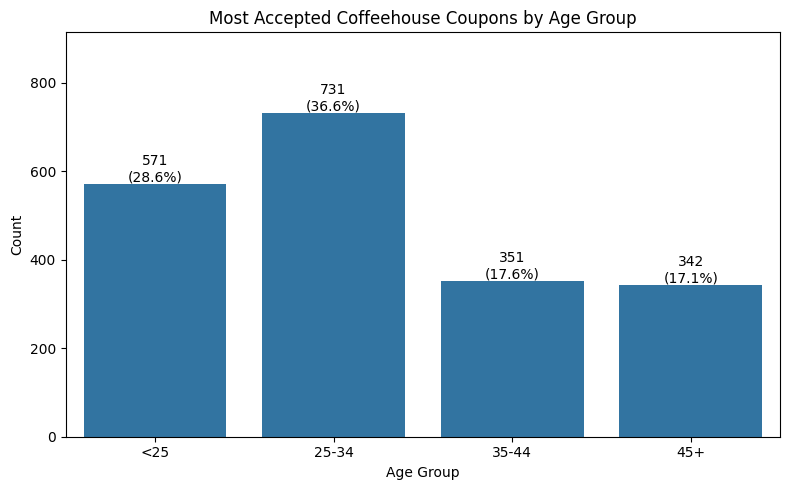

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create age groups
coffee_coupon['age_group'] = pd.cut(
    coffee_coupon['age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=['<25', '25-34', '35-44', '45+']
)

# Filter accepted coupons
accepted = coffee_coupon[coffee_coupon['Y'] == 1]

# Compute counts and percentages
counts = accepted['age_group'].value_counts().sort_index()
percentages = counts / counts.sum() * 100

# Plot
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=accepted,
    x='age_group',
    order=['<25', '25-34', '35-44', '45+']
)

# Add labels on bars
for i, p in enumerate(ax.patches):
    count = counts.iloc[i]
    pct = percentages.iloc[i]
    
    ax.annotate(f'{count}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(counts) * 1.25)

plt.title('Most Accepted Coffeehouse Coupons by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The 25–34 age group drives the highest coupon acceptance at 36.6% (731), followed by those under 25 at 28.6%, meaning about two-thirds of accepted coupons come from people under 35. Acceptance drops sharply for ages 35+ (both \~17%), indicating older groups are significantly less responsive to coffeehouse promotions.

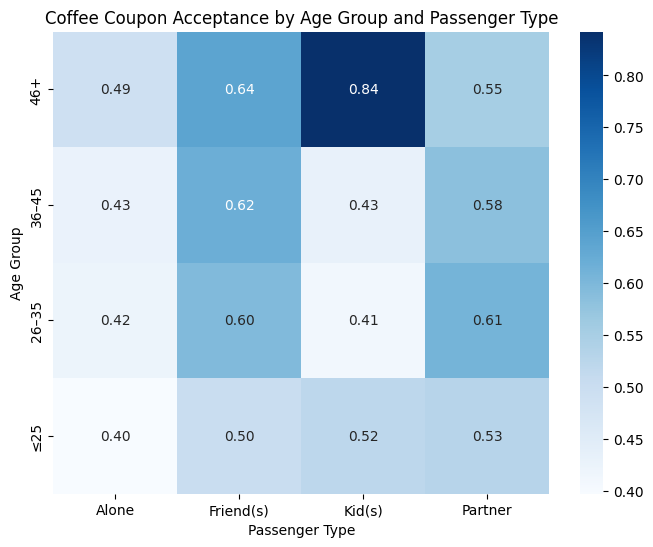

In [26]:
age_order = ['46+', '36–45', '26–35', '≤25']

# Create age_group from age_num
coffee_coupon['age_group'] = pd.cut(
    coffee_coupon['age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=age_order,
    right=True
)

# order categories
coffee_coupon['age_group'] = pd.Categorical(
    coffee_coupon['age_group'],
    categories=age_order,
    ordered=True
)

# Pivot table
pivot = coffee_coupon.pivot_table(
    values='Y',
    index='age_group',
    columns='passanger',
    aggfunc='mean',
    observed=True
).sort_index()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.2f')

plt.title('Coffee Coupon Acceptance by Age Group and Passenger Type')
plt.xlabel('Passenger Type')
plt.ylabel('Age Group')

plt.show()

People are generally more likely to accept coupons when they’re with friends or a partner (\~0.58–0.64) than when they’re alone (\~0.40–0.49). The big standout is the 46+ group with kids, where acceptance jumps really high (0.84), while younger groups are more steady and don’t vary as much by who they’re with.

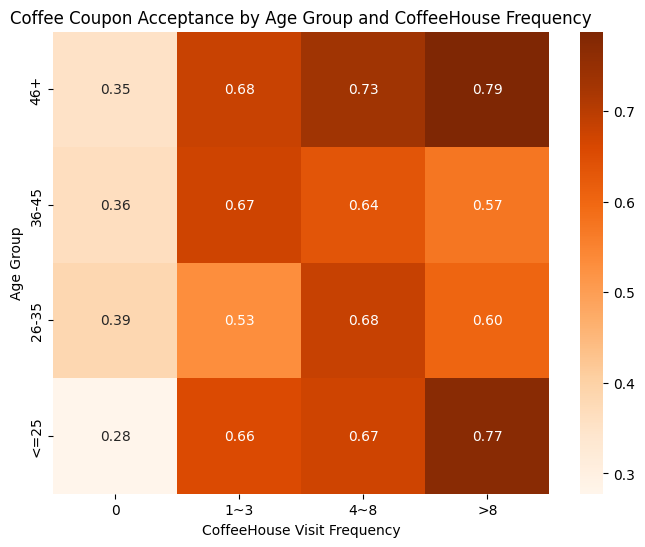

In [27]:
# Exclude Unknown CoffeeHouse values
coffee_coupon_ch = coffee_coupon[coffee_coupon['CoffeeHouse'] != 'Unknown'].copy()

# Define age order
age_order = ['46+', '36-45', '26-35', '<=25']

# Create age_group from age_num
coffee_coupon_ch['age_group'] = pd.cut(
    coffee_coupon_ch['age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=age_order,
    right=True
)

# Order categories
coffee_coupon_ch['age_group'] = pd.Categorical(
    coffee_coupon_ch['age_group'],
    categories=age_order,
    ordered=True
)

# Pivot table: Age Group × CoffeeHouse
pivot = (
    coffee_coupon_ch
    .pivot_table(
        values='Y',
        index='age_group',
        columns='CoffeeHouse',
        aggfunc='mean',
        observed=True
    )
    .sort_index()
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    cmap='Oranges',
    fmt='.2f'
)

plt.title('Coffee Coupon Acceptance by Age Group and CoffeeHouse Frequency')
plt.xlabel('CoffeeHouse Visit Frequency')
plt.ylabel('Age Group')
plt.show()

Coupon acceptance clearly increases with how often people visit coffeehouses— frequent visitors (4–8 or >8 times) have the highest rates across all age groups. The <25 and 46+ groups show especially big jumps at high frequencies (up to \~0.77–0.79), while people who never go (0 visits) have the lowest acceptance (\~0.28–0.39).


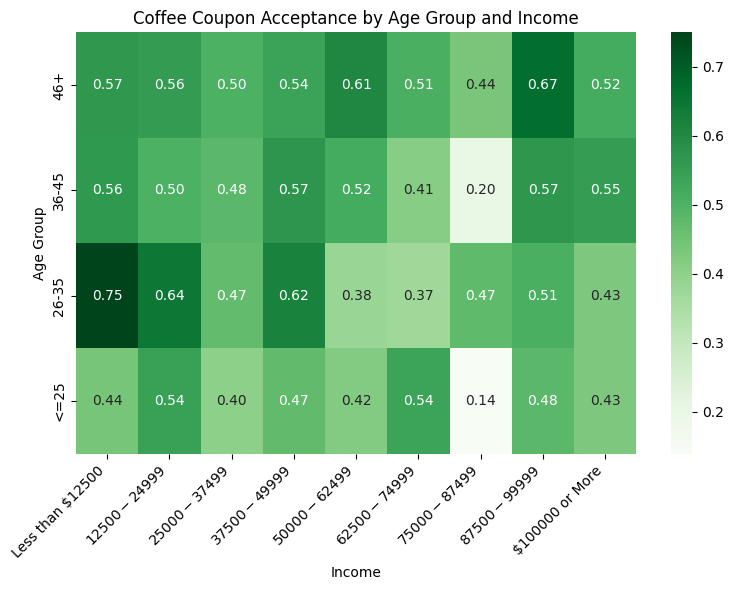

In [28]:
# Exclude Unknown CoffeeHouse values
coffee_coupon_ch = coffee_coupon[coffee_coupon['CoffeeHouse'] != 'Unknown'].copy()

# Define age order
age_order = ['46+', '36-45', '26-35', '<=25']

# Create age_group from age_num
coffee_coupon_ch['age_group'] = pd.cut(
    coffee_coupon_ch['age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=age_order,
    right=True
)

# Order age group
coffee_coupon_ch['age_group'] = pd.Categorical(
    coffee_coupon_ch['age_group'],
    categories=age_order,
    ordered=True
)

# Order income level
income_order = [
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999',
    '$50000 - $62499',
    '$62500 - $74999',
    '$75000 - $87499',
    '$87500 - $99999',
    '$100000 or More'
]

# Convert to ordered categorical
coffee_coupon_ch['income'] = pd.Categorical(
    coffee_coupon_ch['income'],
    categories=income_order,
    ordered=True
)

# Pivot table: Age Group × CoffeeHouse
pivot = (
    coffee_coupon_ch
    .pivot_table(
        values='Y',
        index='age_group',
        columns='income',
        aggfunc='mean',
        observed=True
    )
    .sort_index()
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    cmap='Greens',
    fmt='.2f'
)

plt.title('Coffee Coupon Acceptance by Age Group and Income')
plt.xlabel('Income')
plt.ylabel('Age Group')


# Rotate x-axis labels diagonally
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Coupon acceptance doesn’t follow a simple pattern by income, but there are a couple clear trends.
- Lower-income groups, especially less than 12.5K tend to have higher acceptance— peaking at 0.75 for ages 26–35  
- Mid-to-higher income ranges (like $75K–$87.5K) dip pretty low across age groups
- The 26–35 group stands out as the most responsive overall, with consistently higher acceptance across multiple income levels


In [29]:
# 1. Define attributes

df = coffee_coupon

coffee = df['CoffeeHouse'].isin(['1~3', '4~8', '>8'])
age45 = df['age_num'] > 45
kid = df['passanger'] == 'Kid(s)'

income_lt50 = df['income'].isin([
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
])
income_gt50 = ~income_lt50

cheap_rest = df['RestaurantLessThan20'].isin(['4~8', '>8'])

# 2. Define conditions

A = coffee & age45
B = A & income_gt50
C = B & kid
D = coffee & cheap_rest & income_lt50

# 3. Mutually exclusive groups 

C_only = C
B_only = B & ~C
A_only = A & ~B
D_only = D & ~(A | B | C)
Others = ~(A | B | C | D)

# 4. Build groups

groups = {
    'C: High-income 45+ freq coffee drivers (with kids)': C_only,
    'B: High-income 45+ freq coffee drivers (no kids)': B_only,
    'A: ≤50K 45+ coffee drivers': A_only,
    'D: Low-income freq restaurant drivers': D_only,
    'Others: Remaining drivers': Others
}

# 5. Compute summary table

coffeehouse_acceptance_rates = pd.DataFrame([
    {
        'Segment': name,
        'Sample Size': cond.sum(),
        'Acceptance Rate (%)': df.loc[cond, 'Y'].mean() * 100
    }
    for name, cond in groups.items()
])

# Round only acceptance rate
coffeehouse_acceptance_rates['Acceptance Rate (%)'] = \
    coffeehouse_acceptance_rates['Acceptance Rate (%)'].round(1)

# 6. Display summary table

pd.set_option('display.max_colwidth', None)

coffeehouse_acceptance_rates.style \
    .format({'Acceptance Rate (%)': '{:.1f}'}) \
    .set_properties(
        subset=['Segment'],
        **{'min-width': '400px'}
    )

,Segment,Sample Size,Acceptance Rate (%)
0,C: High-income 45+ freq coffee drivers (with kids),17,76.5
1,B: High-income 45+ freq coffee drivers (no kids),113,59.3
2,A: ≤50K 45+ coffee drivers,184,72.8
3,D: Low-income freq restaurant drivers,378,63.8
4,Others: Remaining drivers,3304,46.6


- The pattern isn’t a simple increase or decrease across age and income groups
- Instead, different combinations of age and income show different acceptance levels, meaning both factors together influence behavior in a more complex way


In [30]:
# Validation to ensure the groupings are mutually exclusive
check_total = sum(cond.sum() for cond in groups.values())
print("Total rows from segments:", check_total)
print("Total rows in dataset:", len(df))

Total rows from segments: 3996
Total rows in dataset: 3996
